In [89]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from statsmodels.tsa.statespace.sarimax import SARIMAX

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [90]:
df = pd.read_excel(r"C:\Users\Amey\Desktop\Amey\Python\100\Preprocessing\100_Pre_done_Combined.xlsx")

df.head()

,Material,SLoc,Quantity,Pstng Date,order,Equipment,Technician name,Year,Tavg,Tmax,Tmin,RH,Month,Season,Delta_T,Region,Location
0,100,5023,-1,2020-01-04,48550533,10930429,Anil Sharma,2020,12.94,21.27,7.26,58.52,1,Winter,14.01,North1,Haryana
1,100,5024,-1,2020-01-06,48556766,10844557,Jogendra Singh,2020,14.94,22.58,9.03,56.47,1,Winter,13.55,North1,Jaipur
2,100,5030,-1,2020-01-06,48550093,10517828,Himanshu Kushwaha,2020,13.70,21.92,8.25,55.23,1,Winter,13.67,North1,Delhi
3,100,5002,-1,2020-01-06,48550185,10519283,Prasad Chokhat,2020,22.83,30.49,16.34,68.83,1,Winter,14.15,West1,Navi Mumbai
4,100,5044,-1,2020-01-06,48554032,10836205,Joby Varghese,2020,28.71,32.68,25.08,68.80,1,Winter,7.60,South,Cochin


In [91]:
df['Pstng Date'] = pd.to_datetime(df['Pstng Date'])

df['Consumption'] = abs(df['Quantity'])

india = (
    df.groupby(
        pd.Grouper(
            key='Pstng Date',
            freq='MS'
        )
    )
    .agg({
        'Consumption':'sum',
        'Tavg':'mean',
        'Tmax':'mean',
        'Tmin':'mean',
        'RH':'mean',
        'Delta_T':'mean'
    })
    .reset_index()
)

india.head()

,Pstng Date,Consumption,Tavg,Tmax,Tmin,RH,Delta_T
0,2020-01-01,82,17.412805,24.657927,11.672317,66.535732,12.985610
1,2020-02-01,86,20.243140,28.964884,13.327209,51.149419,15.637674
2,2020-03-01,64,23.336452,31.135161,16.846935,54.755968,14.288226
3,2020-04-01,16,28.129375,35.836875,20.638125,43.636875,15.198750
4,2020-05-01,20,33.021000,40.285500,26.661000,44.450500,13.624500


In [92]:
india['Month'] = india['Pstng Date'].dt.month
india['Quarter'] = india['Pstng Date'].dt.quarter

india['month_sin'] = np.sin(
    2 * np.pi * india['Month'] / 12
)

india['month_cos'] = np.cos(
    2 * np.pi * india['Month'] / 12
)
# Lag Features
for lag in [1,2,3,6,12]:
    india[f'lag_{lag}'] = india['Consumption'].shift(lag)

# Rolling Features
india['roll_mean_3'] = (
    india['Consumption']
    .shift(1)
    .rolling(3)
    .mean()
)

india['roll_mean_6'] = (
    india['Consumption']
    .shift(1)
    .rolling(6)
    .mean()
)

india['roll_std_3'] = (
    india['Consumption']
    .shift(1)
    .rolling(3)
    .std()
)
india['roll_mean_12'] = (
    india['Consumption']
    .shift(1)
    .rolling(12)
    .mean()
)

india['roll_std_12'] = (
    india['Consumption']
    .shift(1)
    .rolling(12)
    .std()
)

india = india.dropna()

india.head()

,Pstng Date,Consumption,Tavg,Tmax,Tmin,RH,Delta_T,Month,Quarter,month_sin,...,lag_1,lag_2,lag_3,lag_6,lag_12,roll_mean_3,roll_mean_6,roll_std_3,roll_mean_12,roll_std_12
12,2021-01-01,122,19.240673,27.109519,13.418077,57.501731,13.691442,1,1,0.500000,...,110.0,97.0,122.0,86.0,82.0,109.666667,97.833333,12.503333,80.333333,32.883633
13,2021-02-01,131,21.361069,30.375420,14.089847,41.907939,16.285573,2,1,0.866025,...,122.0,110.0,97.0,87.0,86.0,109.666667,103.833333,12.503333,83.666667,35.025532
14,2021-03-01,145,27.023819,36.155000,19.404861,32.799514,16.750139,3,1,1.000000,...,131.0,122.0,110.0,85.0,64.0,121.000000,111.166667,10.535654,87.416667,37.611551
15,2021-04-01,107,29.541121,38.286075,21.460561,29.022710,16.825514,4,2,0.866025,...,145.0,131.0,122.0,122.0,16.0,132.666667,121.166667,11.590226,94.166667,40.205909
16,2021-05-01,86,30.838372,36.796977,25.563488,52.874884,11.233488,5,2,0.500000,...,107.0,145.0,131.0,97.0,20.0,127.666667,118.666667,19.218047,101.750000,31.832302


In [93]:
train = india[
    india['Pstng Date'] < '2025-01-01'
]

test = india[
    india['Pstng Date'] >= '2025-01-01'
]

print(train.shape)
print(test.shape)

(48, 21)
(16, 21)


In [94]:
FEATURES = [

    'month_sin',
    'month_cos',
    'Quarter',

    'lag_1',
    'lag_2',
    'lag_3',
    'lag_6',
    'lag_12',

    'roll_mean_3',
    'roll_mean_6',
    'roll_std_3',
    'roll_std_12',
    'roll_mean_12',

    'Tavg',
    'Tmax',
    'Tmin',
    'RH',
    'Delta_T'
]

TARGET = 'Consumption'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]


def evaluate_model(y_true,y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mape = np.mean(
        np.abs(
            (y_true-y_pred)/y_true
        )
    )*100

    wape = (
        np.sum(np.abs(y_true-y_pred))
        /
        np.sum(y_true)
    )*100

    return mae,rmse,mape,wape

In [95]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

In [96]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train,y_train)

xgb_pred = xgb.predict(X_test)

In [97]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=5,
    max_depth=3,
    min_child_samples=5,
    random_state=42,
    verbosity=-1
)

lgbm.fit(X_train,y_train)

lgbm_pred = lgbm.predict(X_test)

In [98]:
cat = CatBoostRegressor(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    random_seed=42,
    verbose=False
)

cat.fit(X_train,y_train)

cat_pred = cat.predict(X_test)

In [ ]:
exog_train = train[
    [
        'Tavg',
        'Tmax',
        'Tmin',
        'RH',
        'Delta_T'
    ]
]

exog_test = test[
    [
        'Tavg',
        'Tmax',
        'Tmin',
        'RH',
        'Delta_T'
    ]
]
sarimax = SARIMAX(
    y_train,
    exog=exog_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarimax_fit = sarimax.fit(disp=False)

sarimax_pred = sarimax_fit.forecast(
    len(test),
    exog=exog_test
)

In [100]:
results = []

models = {
    'RandomForest':rf_pred,
    'XGBoost':xgb_pred,
    'LightGBM':lgbm_pred,
    'CatBoost':cat_pred,
    'SARIMAX':sarimax_pred
}

for model_name,preds in models.items():

    mae,rmse,mape,wape = evaluate_model(
        y_test,
        preds
    )

    results.append([
        model_name,
        mae,
        rmse,
        mape,
        wape
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'MAE',
        'RMSE',
        'MAPE',
        'WAPE'
    ]
)

results_df.sort_values(
    'WAPE'
)

,Model,MAE,RMSE,MAPE,WAPE
2,LightGBM,50.219286,61.375469,11.665998,11.294751
1,XGBoost,55.071968,67.171237,13.753684,12.386161
0,RandomForest,55.392375,64.924051,13.626552,12.458223
4,SARIMAX,58.667217,68.482729,14.236631,13.194763
3,CatBoost,59.155440,67.989399,13.378965,13.304569


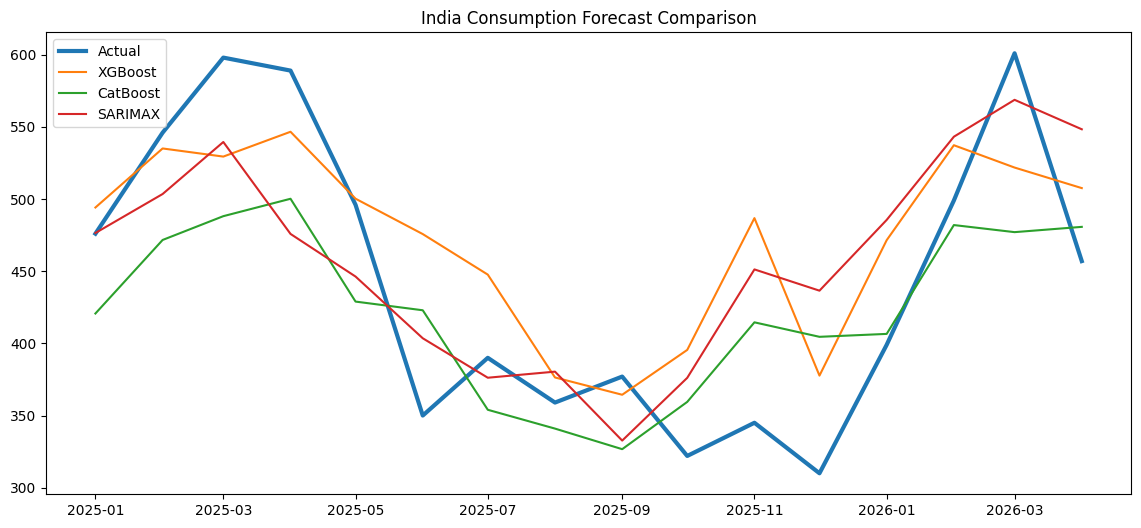

In [101]:
plt.figure(figsize=(14,6))

plt.plot(
    test['Pstng Date'],
    y_test,
    label='Actual',
    linewidth=3
)

plt.plot(
    test['Pstng Date'],
    xgb_pred,
    label='XGBoost'
)

plt.plot(
    test['Pstng Date'],
    cat_pred,
    label='CatBoost'
)

plt.plot(
    test['Pstng Date'],
    sarimax_pred,
    label='SARIMAX'
)

plt.legend()

plt.title(
    "India Consumption Forecast Comparison"
)

plt.show()

In [102]:
importance = pd.DataFrame({
    'Feature':FEATURES,
    'Importance':xgb.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

importance

,Feature,Importance
3,lag_1,0.246450
7,lag_12,0.242193
8,roll_mean_3,0.145309
9,roll_mean_6,0.071291
11,roll_std_12,0.052797
12,roll_mean_12,0.045944
4,lag_2,0.037424
17,Delta_T,0.026119
13,Tavg,0.025370
16,RH,0.021712


In [103]:
ensemble_pred = (
    0.6*xgb_pred
    +
    0.4*sarimax_pred
)

mae,rmse,mape,wape = evaluate_model(
    y_test,
    ensemble_pred
)

print("Ensemble WAPE:",wape)

Ensemble WAPE: 12.482817241868883


In [104]:
importance = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': cat.get_feature_importance()
})

importance.sort_values(
    'Importance',
    ascending=False
)

,Feature,Importance
3,lag_1,14.291079
7,lag_12,11.647913
11,roll_std_12,8.488541
4,lag_2,7.709069
12,roll_mean_12,6.488503
17,Delta_T,5.798174
0,month_sin,5.614081
16,RH,5.104420
9,roll_mean_6,5.018102
8,roll_mean_3,4.470865


In [105]:
print(india['Consumption'].describe())

count     64.00000
mean     319.96875
std      141.44537
min       86.00000
25%      206.25000
50%      316.50000
75%      407.50000
max      601.00000
Name: Consumption, dtype: float64
